# AeroNet Lite — Autonomous Drone Delivery Simulation

## Project Overview

**AeroNet Lite** is a complete multi-module AI simulation of an autonomous drone delivery network operating over a 10×10 urban grid. The system integrates five AI sub-systems:

| Module | File | AI Technique |
|--------|------|--------------|
| Grid Model | `module_0.py` | Data modelling (CSP state space) |
| Layout Validator | `module_1.py` | Constraint Satisfaction Problem (CSP) |
| Fleet Selector | `module_2.py` | Genetic Algorithm optimisation |
| Route Planner | `module_3.py` | A* Search (heuristic pathfinding) |
| Delivery Simulator | `module_4.py` | Event-driven simulation |
| ML Pipeline | `module_5.py` | Random Forest / multi-class classification |

---

## Execution Order

Run cells **top to bottom**. Each section corresponds to a named simulation step (Steps 1–20). The notebook is self-contained: all imports, data generation, and visualisation happen inline.

**Pre-requisites:** `numpy`, `pandas`, `scikit-learn`, `matplotlib` — all standard Anaconda/pip packages.

---
## Setup — Path Configuration

We add the `src/` directory to `sys.path` so Python can find `module_0` through `module_5` and `visualization`. This must be executed first.

In [45]:
import sys
import os

src_path = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print("Source path configured:", src_path)

Source path configured: /src


---
## Module 0 — Grid Model (`module_0.py`)

### What it does

The grid is the shared state space for the entire simulation. `create_grid()` builds a **10×10 matrix** of `Cell` dataclass instances, each tagged with:

- **zone** — one of: Residential, Commercial, Industrial, Hospital, School, Open Field
- **density** — population/activity intensity (used for initial demand)
- **is_hub** — drone dispatch/return point (hubs at `(1,4)`, `(5,3)`, `(7,5)`)
- **is_charging** — charging pad adjacent to hub
- **is_medical_pickup** — medical delivery origin
- **no_fly** — dynamically set during simulation
- **demand** — float, updated by ML forecast in Module 5

### Step 1 — Initialise Grid

In [46]:
from module_0 import create_grid, print_grid_summary, get_cells_by

grid = create_grid(seed=42)

print("Grid created — 10x10 cells")
print_grid_summary(grid)

Grid created — 10x10 cells
  Hubs           : [(1, 4), (5, 3), (7, 5)]
  Charging pads  : [(1, 5), (5, 4), (7, 4)]
  Medical pickups: [(6, 0)]
  Hospitals      : [(5, 0)]
  No-fly cells   : []


### Zone Map Visualisation

Each cell is colour-coded by zone type. Hub positions are marked with a star (`*`), charging pads with `C`, and medical pickup with `+`.

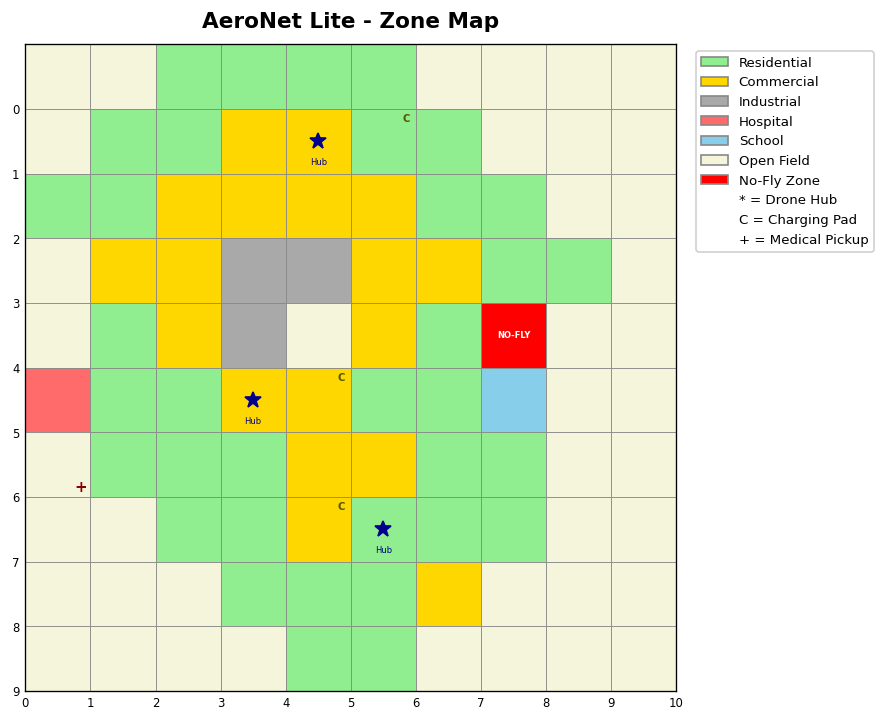

In [70]:
from visualization import plot_zone_map
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")

path = plot_zone_map(grid)
from IPython.display import Image
Image(path)

---
## Module 1 — Layout Validator (`module_1.py`)

### What it does

This module implements a **Constraint Satisfaction Problem (CSP)** to verify that the urban grid layout obeys four planning rules before any drone is deployed:

| Rule | Constraint |
|------|------------|
| R1 | No Industrial cell may be adjacent (4-connected) to a Hospital or School |
| R2 | Every Residential cell must have a drone hub within Manhattan distance ≤ 3 |
| R3 | Every hub must have a charging pad within Manhattan distance ≤ 2 |
| R4 | At least one Hospital must have a medical pickup within distance ≤ 1 |

The validator returns a result dict with keys `passed`, `failed`, `errors`, `valid`, and `details`. A failed rule does **not** abort the simulation — it surfaces actionable diagnostics.

### Step 2 — Validate Layout

In [48]:
from module_1 import validate_layout, print_validation_report

report = validate_layout(grid)
print_validation_report(report)

print(f"Rules passed : {report['passed']}")
print(f"Rules failed : {report['failed']}")
print(f"Layout valid : {report['valid']}")


  Layout Validation Report
  PASSED: R1, R3, R4
  FAILED: R2

  [R1] PASSED - constraint satisfied.

  [R2] FAILED (7 violation(s)):
    - R2 FAIL: Residential at (2,0) has no hub within 3 cells. Nearest hub: (1, 4) (dist 5). Suggested fix: add a hub near (1,0) or convert cell to Open Field.
    - R2 FAIL: Residential at (2,1) has no hub within 3 cells. Nearest hub: (1, 4) (dist 4). Suggested fix: add a hub near (1,1) or convert cell to Open Field.
    - R2 FAIL: Residential at (2,7) has no hub within 3 cells. Nearest hub: (1, 4) (dist 4). Suggested fix: add a hub near (1,7) or convert cell to Open Field.
    - R2 FAIL: Residential at (3,7) has no hub within 3 cells. Nearest hub: (1, 4) (dist 5). Suggested fix: add a hub near (2,7) or convert cell to Open Field.
    - R2 FAIL: Residential at (3,8) has no hub within 3 cells. Nearest hub: (1, 4) (dist 6). Suggested fix: add a hub near (2,8) or convert cell to Open Field.
    - R2 FAIL: Residential at (4,6) has no hub within 3 cells. Nea

---
## Module 2 — Fleet Selector (`module_2.py`)

### What it does

We need to choose how many **light** (2 kg payload, range 12) and **heavy** (5 kg payload, range 20) drones to deploy within a **budget of 10,000 units**.

The module solves this as an **optimisation problem** using a **Genetic Algorithm (GA)**:

- **Chromosome**: `[n_light, n_heavy]` — two integer genes
- **Fitness function**: `0.75 × coverage% − 0.25 × budget_used%`  
  - Maximises delivery coverage, penalises overspending
- **Parameters**: population = 30, generations = 60, mutation rate = 0.15
- **Operators**: tournament selection (k=3), single-point crossover, ±1 mutation

A brute-force baseline is also available (`select_fleet_brute`) for comparison.

### Step 3 — Select Fleet

In [49]:
from module_2 import select_fleet, select_fleet_brute, print_fleet_report, create_drone_objects

fleet_result = select_fleet(grid, budget=10_000)
print_fleet_report(fleet_result)

brute_result = select_fleet_brute(grid, budget=10_000)
print(f"\nBrute Force comparison: {brute_result['light']} light + {brute_result['heavy']} heavy  "
      f"(score {brute_result['score']})")
print(f"Genetic Algorithm:      {fleet_result['light']} light + {fleet_result['heavy']} heavy  "
      f"(score {fleet_result['score']})")


  Fleet Selection
  Method        : Genetic Algorithm
  Budget        : 10,000 units
  Light drones  : 10  (1,000 each | 12-cell range | 2kg)
  Heavy drones  : 0  (1,800 each | 20-cell range | 5kg)
  Total cost    : 10,000 units  (100.0% of budget)
  Coverage score: 16.67


Brute Force comparison: 10 light + 0 heavy  (score 16.67)
Genetic Algorithm:      10 light + 0 heavy  (score 16.67)


---
## Module 4 — Delivery Simulator (`module_4.py`) — Fleet & Delivery Setup

### What it does

`build_fleet` instantiates `Drone` dataclass objects from the GA result, assigning each drone to a hub. `generate_deliveries` randomly creates 8 delivery tasks between commercial/medical origins and residential destinations.

### Step 4 — Build Fleet & Generate Deliveries

In [50]:
from module_4 import (
    build_fleet, generate_deliveries, assign_deliveries, move_drones,
    activate_nofly, reroute_drones, inject_anomaly, simulation_summary,
)

drones = build_fleet(fleet_result, grid)
print(f"Fleet built: {len(drones)} drones")
for d in drones:
    print(f"  {d.drone_id} ({d.drone_type}) | hub={d.hub} | payload={d.payload_kg}kg | battery={d.battery}%")

deliveries = generate_deliveries(grid, count=8, seed=7)
print(f"\n{len(deliveries)} deliveries generated:")
for d in deliveries:
    print(f"  {d.delivery_id}: {d.pickup} -> {d.dropoff}  ({d.payload_kg}kg)")

Fleet built: 10 drones
  D1 (light) | hub=(1, 4) | payload=2.0kg | battery=100.0%
  D2 (light) | hub=(5, 3) | payload=2.0kg | battery=100.0%
  D3 (light) | hub=(7, 5) | payload=2.0kg | battery=100.0%
  D4 (light) | hub=(1, 4) | payload=2.0kg | battery=100.0%
  D5 (light) | hub=(5, 3) | payload=2.0kg | battery=100.0%
  D6 (light) | hub=(7, 5) | payload=2.0kg | battery=100.0%
  D7 (light) | hub=(1, 4) | payload=2.0kg | battery=100.0%
  D8 (light) | hub=(5, 3) | payload=2.0kg | battery=100.0%
  D9 (light) | hub=(7, 5) | payload=2.0kg | battery=100.0%
  D10 (light) | hub=(1, 4) | payload=2.0kg | battery=100.0%

8 deliveries generated:
  DEL_01: (4, 2) -> (2, 1)  (4.5kg)
  DEL_02: (1, 4) -> (1, 1)  (1.5kg)
  DEL_03: (4, 5) -> (0, 5)  (2.0kg)
  DEL_04: (1, 4) -> (1, 2)  (4.5kg)
  DEL_05: (5, 4) -> (1, 1)  (2.0kg)
  DEL_06: (2, 2) -> (9, 5)  (4.5kg)
  DEL_07: (1, 4) -> (1, 6)  (2.0kg)
  DEL_08: (6, 0) -> (0, 5)  (4.5kg)


---
## Module 3 — Route Planner (`module_3.py`)

### What it does

**A* Search** finds the optimal path for each drone. The grid is a weighted graph:

- **Heuristic**: Manhattan distance to goal (admissible, consistent)
- **Edge cost**: 0.8 for Commercial cells (high-traffic corridors), 1.0 for all others
- **No-fly cells** are treated as impassable walls
- **Returns**: `(path, cost)` tuple or `(None, None)` if unreachable

`plan_delivery_route` chains three A* legs: `hub → pickup → dropoff → hub`, returning `full_path` and `total_cost`.

### Step 5 — Assign Deliveries via A*

In [51]:
from module_3 import astar, astar_result, plan_delivery_route

assign_log = []
assign_deliveries(deliveries, drones, grid, assign_log)

for entry in assign_log:
    print(entry)

assigned = sum(1 for d in deliveries if d.status == "assigned")
pending  = sum(1 for d in deliveries if d.status == "pending")
print(f"\nAssigned: {assigned}  |  Pending (payload mismatch): {pending}")

  [DEL_01] No available drone with sufficient payload (4.5kg required, 2.0kg available).
  DEL_02 assigned to D1 (light). Route: (1, 4) -> (1, 1). Cost: 5.4.
  DEL_03 assigned to D2 (light). Route: (4, 5) -> (0, 5). Cost: 12.4.
  [DEL_04] No available drone with sufficient payload (4.5kg required, 2.0kg available).
  DEL_05 assigned to D5 (light). Route: (5, 4) -> (1, 1). Cost: 12.4.
  [DEL_06] No available drone with sufficient payload (4.5kg required, 2.0kg available).
  DEL_07 assigned to D4 (light). Route: (1, 4) -> (1, 6). Cost: 3.8.
  [DEL_08] No available drone with sufficient payload (4.5kg required, 2.0kg available).

Assigned: 4  |  Pending (payload mismatch): 4


### A* Single-Path Demo

Demonstrate A* directly between two cells to show path and cost:

In [52]:
start, goal = (5, 3), (1, 1)
res = astar_result(start, goal, grid)
print(f"A* from {start} to {goal}")
print(f"  Found  : {res['found']}")
print(f"  Steps  : {len(res['path'])}")
print(f"  Cost   : {res['cost']}")
print(f"  Path   : {res['path']}")

A* from (5, 3) to (1, 1)
  Found  : True
  Steps  : 7
  Cost   : 5.4
  Path   : [(5, 3), (4, 3), (4, 2), (3, 2), (2, 2), (1, 2), (1, 1)]


### Step 6 — Route Map

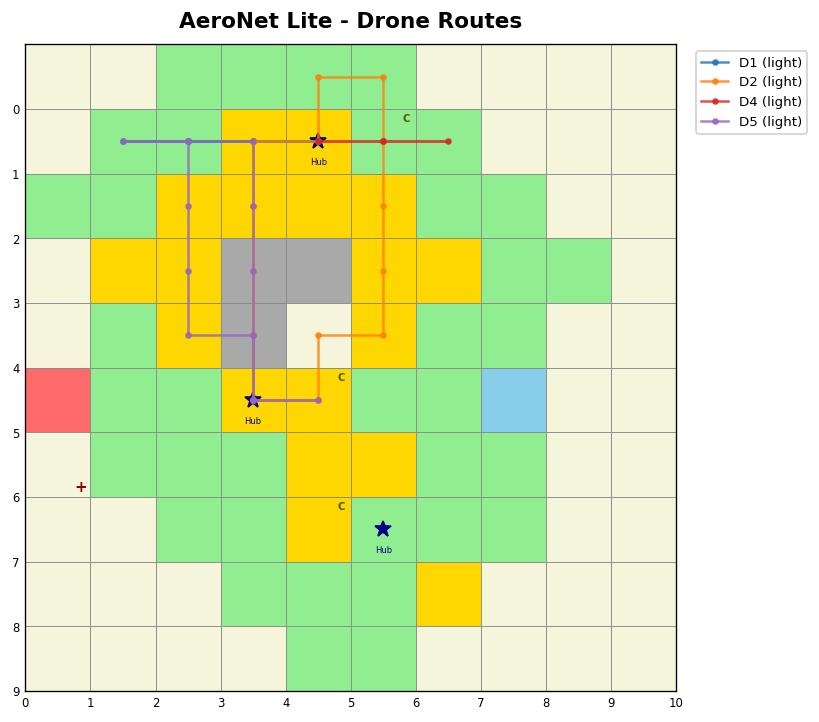

In [53]:
from visualization import plot_route_map
from IPython.display import Image

path = plot_route_map(grid, drones, deliveries)
Image(path)

---
## Simulation Steps 7–10 — Normal Drone Movement

Each call to `move_drones` advances all `en_route` drones by one cell along their planned A* path. Battery decreases by `battery_drain_per_step` (5.0% for light, 3.5% for heavy). When a drone reaches the final cell of its route, the delivery is marked `completed` and the drone returns to `idle` at its hub.

In [54]:
step_log = []

for step in range(7, 11):
    move_drones(drones, deliveries, step_log)
    positions  = {d.drone_id: d.position for d in drones if d.status == "en_route"}
    completed  = sum(1 for d in deliveries if d.status == "completed")
    print(f"Step {step}: en-route={positions}  completed_so_far={completed}")

print("\nAll step log entries:")
for entry in step_log[-8:]:
    print(" ", entry)

Step 7: en-route={'D1': (1, 3), 'D2': (5, 4), 'D4': (1, 5), 'D5': (5, 4)}  completed_so_far=0
Step 8: en-route={'D1': (1, 2), 'D2': (4, 4), 'D4': (1, 6), 'D5': (5, 3)}  completed_so_far=0
Step 9: en-route={'D1': (1, 1), 'D2': (4, 5), 'D4': (1, 5), 'D5': (4, 3)}  completed_so_far=0
Step 10: en-route={'D1': (1, 2), 'D2': (3, 5), 'D5': (4, 2)}  completed_so_far=1

All step log entries:
    D4 completed delivery DEL_07. Returned to hub (1, 4).


---
## Step 11 — Disruption: No-Fly Cell Activated

At step 11, cell `(4, 7)` is declared a **no-fly zone** (emergency ground closure, airspace restriction, etc.).

`activate_nofly(row, col, grid, drones)` sets `grid[4][7].no_fly = True` and returns the IDs of any drones whose remaining routes pass through that cell — these drones will be rerouted in the next steps.

In [55]:
no_fly_cell = (4, 7)
affected = activate_nofly(no_fly_cell[0], no_fly_cell[1], grid, drones)

print(f"No-fly zone activated at {no_fly_cell}")
print(f"Drones with routes passing through {no_fly_cell}: {affected if affected else 'none'}")
print(f"Cell {no_fly_cell} no_fly flag: {grid[4][7].no_fly}")

No-fly zone activated at (4, 7)
Drones with routes passing through (4, 7): none
Cell (4, 7) no_fly flag: True


---
## Steps 12–14 — Real-Time Rerouting

`reroute_drones` scans every `en_route` drone's remaining path. If any future waypoint overlaps a no-fly cell, it re-runs A* from the drone's **current position** to the **original destination**, generating a new collision-free path.

This loop runs for 3 steps to let all disrupted drones settle on valid routes, interleaved with normal movement.

In [56]:
for step in range(12, 15):
    reroute_log = []
    reroute_drones(drones, deliveries, grid, reroute_log)
    for entry in reroute_log:
        print(f"Step {step}: {entry.strip()}")
    move_drones(drones, deliveries, [])
    en_route  = sum(1 for d in drones if d.status == "en_route")
    completed = sum(1 for d in deliveries if d.status == "completed")
    print(f"Step {step}: en_route={en_route}  completed={completed}\n")

Step 12: en_route=3  completed=1

Step 13: en_route=2  completed=2

Step 14: en_route=2  completed=2



---
## Module 5 — ML Pipeline: Demand Forecasting (`module_5.py`)

### What it does

A **Random Forest Regressor** is trained on a synthetic 1,200-row dataset modelled after real bike-sharing demand data. Features include time-of-day, season, temperature, weather, and zone density.

**Demand features**: `hour, day, month, season, temp, humidity, weather, zone_density`

After training, the model forecasts demand for every cell in the grid and writes the values to `cell.demand`. This triggers re-dispatch of pending deliveries in high-demand zones.

Two models are compared:
- **Linear Regression** — baseline
- **Random Forest** — final model (lower MAE/RMSE)

### Steps 15–17 — Demand Forecast & Re-Dispatch

In [57]:
from module_5 import run_demand_forecast

demand_result = run_demand_forecast(grid=grid, verbose=True)

print(f"\nLinear Regression  MAE={demand_result['lr_mae']}  RMSE={demand_result['lr_rmse']}")
print(f"Random Forest      MAE={demand_result['rf_mae']}  RMSE={demand_result['rf_rmse']}")


  DEMAND FORECASTING RESULTS
  Dataset    : synthetic (n=1200, Bike-Sharing style)
  Features   : ['hour', 'day', 'month', 'season', 'temp', 'humidity', 'weather', 'zone_density']
  Model      : Random Forest Regressor (n_estimators=100)
  Linear Regression  ->  MAE=5.657  |  RMSE=7.726
  Random Forest      ->  MAE=1.334  |  RMSE=2.174
  Sample forecast    : Hour 14 demand = 33.76 (scaled: 6.76)
  Demand mapped to grid: 100 zones updated.


Linear Regression  MAE=5.657  RMSE=7.726
Random Forest      MAE=1.334  RMSE=2.174


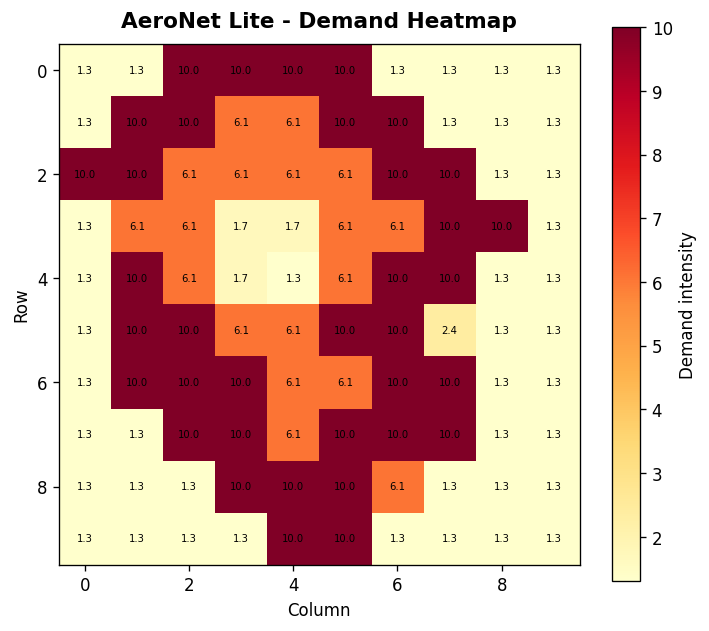

In [58]:
from visualization import plot_demand_heatmap
from IPython.display import Image

path = plot_demand_heatmap(grid)
Image(path)

In [59]:
high_demand = max(
    [(r, c) for r in range(10) for c in range(10) if grid[r][c].zone == "Residential"],
    key=lambda pos: grid[pos[0]][pos[1]].demand,
)
print(f"Highest demand residential cell: {high_demand}  "
      f"(demand={grid[high_demand[0]][high_demand[1]].demand:.2f})")

extra = next((d for d in deliveries if d.status == "pending"), None)
if extra:
    print(f"Re-dispatching {extra.delivery_id} to high-demand zone...")
    extra_log = []
    assign_deliveries([extra], drones, grid, extra_log)
    for entry in extra_log:
        print(" ", entry)
else:
    print("No pending deliveries to re-dispatch.")

Highest demand residential cell: (0, 2)  (demand=10.00)
Re-dispatching DEL_01 to high-demand zone...
    [DEL_01] No available drone with sufficient payload (4.5kg required, 2.0kg available).


---
## Module 5 — ML Pipeline: Anomaly Detection

### What it does

A **multi-class flight anomaly classifier** is trained on 800 synthetic drone telemetry records across 4 classes:

| Class | Label | Key Signal |
|-------|-------|------------|
| 0 | Normal | All readings in normal range |
| 1 | Battery Anomaly | `battery_drop` > 5.1% per step |
| 2 | Route Anomaly | `route_deviation` > 3.1 km |
| 3 | Sensor Spike | Extreme `altitude_change` / `speed_change` |

**Four classifiers** are evaluated side-by-side:
- Decision Tree (depth=6)
- **Random Forest** (100 trees) ← selected as production model
- KNN (k=5)
- Gaussian Naive Bayes

### Step 18 — Train & Classify

In [60]:
from module_5 import train_anomaly_model, classify_drone_telemetry

anomaly_result = train_anomaly_model(verbose=True)
clf = anomaly_result["model"]


  ANOMALY DETECTION RESULTS
  Dataset    : synthetic flight telemetry (n=800, 4 classes)
  Features   : ['battery_drop', 'route_deviation', 'altitude_change', 'speed_change']

  Model Comparison:
    Decision Tree (depth=6)  : 100.00%
    Random Forest (100 trees): 100.00%  <- best
    KNN (k=5)                : 100.00%
    Gaussian NB              : 100.00%

  Random Forest - Confusion Matrix (rows=actual, cols=predicted):
                Normal  Battery An  Route Anom  Sensor Spi
      Normal          44           0           0           0
  Battery An           0          45           0           0
  Route Anom           0           0          33           0
  Sensor Spi           0           0           0          38

  Classification Report:
                 precision    recall  f1-score   support

         Normal       1.00      1.00      1.00        44
Battery Anomaly       1.00      1.00      1.00        45
  Route Anomaly       1.00      1.00      1.00        33
   Sensor Spi

In [61]:
anomaly_log = []

d3 = next((dr for dr in drones if dr.drone_id == "D3"), None)
target_drone = d3 if d3 else (drones[0] if drones else None)

if target_drone:
    inject_anomaly(target_drone, "battery", [])
    anomaly_type = classify_drone_telemetry(
        clf, battery_drop=35.0, speed_change=0.5,
        altitude_change=0.5, route_deviation=0.8
    )
    print(f"Drone {target_drone.drone_id}: classified as '{anomaly_type}'")
    print(f"  Battery after anomaly injection: {target_drone.battery:.1f}%")
    anomaly_log.append({"drone": target_drone.drone_id, "type": anomaly_type,
                        "battery_drop": 35.0, "route_deviation": 0.8})

print("\nClassifying remaining drones (normal telemetry):")
for dr in drones:
    if target_drone and dr.drone_id == target_drone.drone_id:
        continue
    t = classify_drone_telemetry(clf, 1.5, 1.0, 0.3, 0.2)
    anomaly_log.append({"drone": dr.drone_id, "type": t,
                        "battery_drop": 1.5, "route_deviation": 0.2})
    print(f"  {dr.drone_id}: '{t}'")

Drone D3: classified as 'Battery Anomaly'
  Battery after anomaly injection: 60.0%

Classifying remaining drones (normal telemetry):
  D1: 'Normal'
  D2: 'Normal'
  D4: 'Normal'
  D5: 'Normal'
  D6: 'Normal'
  D7: 'Normal'
  D8: 'Normal'
  D9: 'Normal'
  D10: 'Normal'


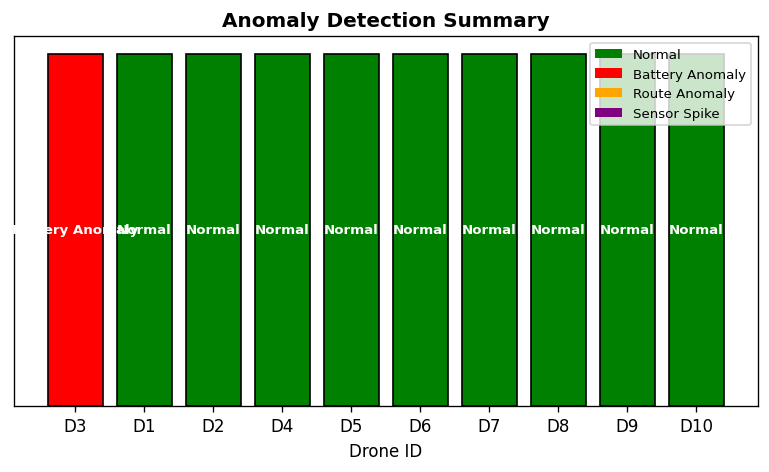

In [62]:
from visualization import plot_anomaly_summary
from IPython.display import Image

path = plot_anomaly_summary(anomaly_log)
Image(path)

---
## Step 19 — Post-Anomaly Response

If the target drone is in `returning` status (battery critically low after anomaly injection), it is navigated back to its hub. Otherwise, all drones advance one more step along their routes.

In [63]:
if target_drone is not None and target_drone.status == "returning":
    target_drone.position = target_drone.hub
    target_drone.status   = "idle"
    print(f"{target_drone.drone_id} returned to hub {target_drone.hub} — status: idle")
else:
    move_drones(drones, deliveries, [])
    completed = sum(1 for d in deliveries if d.status == "completed")
    print(f"Drones advanced one step. Total completed: {completed}")

Drones advanced one step. Total completed: 2


---
## Step 20 — Final Simulation Summary

The simulation ends here. `simulation_summary` tallies all delivery statuses into a final report. The four possible terminal states are:

- **completed** — drone reached dropoff and returned to hub
- **delayed** — drone failed to reroute after no-fly activation
- **failed** — no valid path existed at assignment time
- **pending** — never assigned (payload exceeded fleet capacity)

In [64]:
summary = simulation_summary(deliveries)

print("=" * 50)
print("  FINAL SIMULATION SUMMARY")
print("=" * 50)
print(f"  Completed : {summary['completed']}")
print(f"  Delayed   : {summary['delayed']}")
print(f"  Failed    : {summary['failed']}")
print(f"  Pending   : {summary['pending']}")
print("=" * 50)

print(f"\n{'ID':<10} {'Pickup':<10} {'Dropoff':<10} {'Payload':>7}  {'Status':<12}  Drone")
print("-" * 60)
for d in deliveries:
    print(f"{d.delivery_id:<10} {str(d.pickup):<10} {str(d.dropoff):<10} "
          f"{d.payload_kg:>6.1f}kg  {d.status:<12}  {d.assigned_drone or '-'}")

  FINAL SIMULATION SUMMARY
  Completed : 2
  Delayed   : 0
  Failed    : 0
  Pending   : 6

ID         Pickup     Dropoff    Payload  Status        Drone
------------------------------------------------------------
DEL_01     (4, 2)     (2, 1)        4.5kg  pending       -
DEL_02     (1, 4)     (1, 1)        1.5kg  completed     D1
DEL_03     (4, 5)     (0, 5)        2.0kg  assigned      D2
DEL_04     (1, 4)     (1, 2)        4.5kg  pending       -
DEL_05     (5, 4)     (1, 1)        2.0kg  assigned      D5
DEL_06     (2, 2)     (9, 5)        4.5kg  pending       -
DEL_07     (1, 4)     (1, 6)        2.0kg  completed     D4
DEL_08     (6, 0)     (0, 5)        4.5kg  pending       -


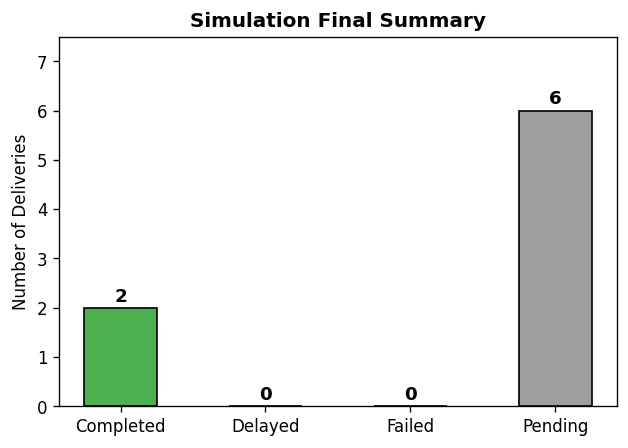

In [65]:
from visualization import plot_simulation_summary
from IPython.display import Image

path = plot_simulation_summary(summary)
Image(path)

---
## Full Run — All Figures Side by Side

Generate and display all five report figures in one pass using `generate_all_figures`.


### Zone Map


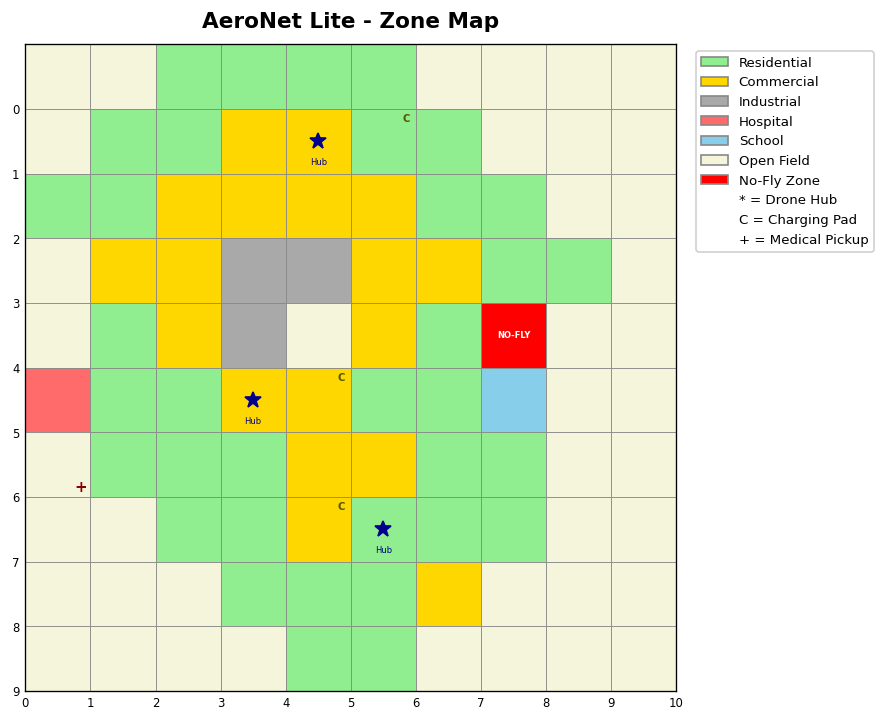


### Route Map


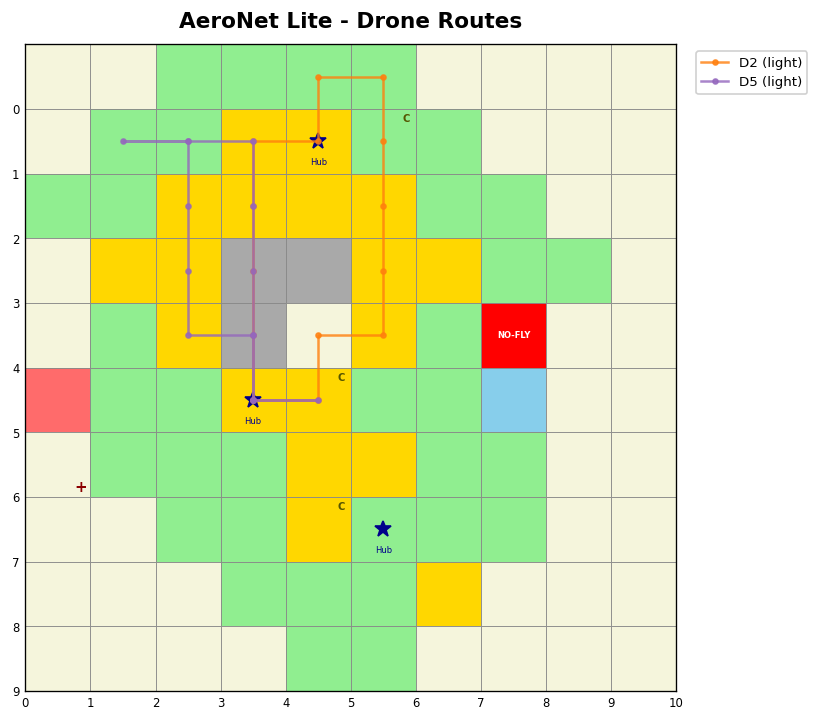


### Demand Heatmap


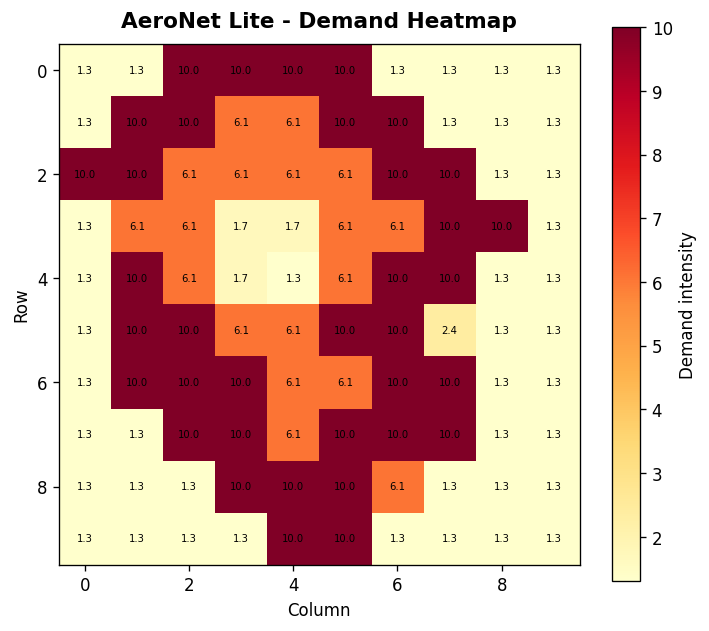


### Anomaly Summary


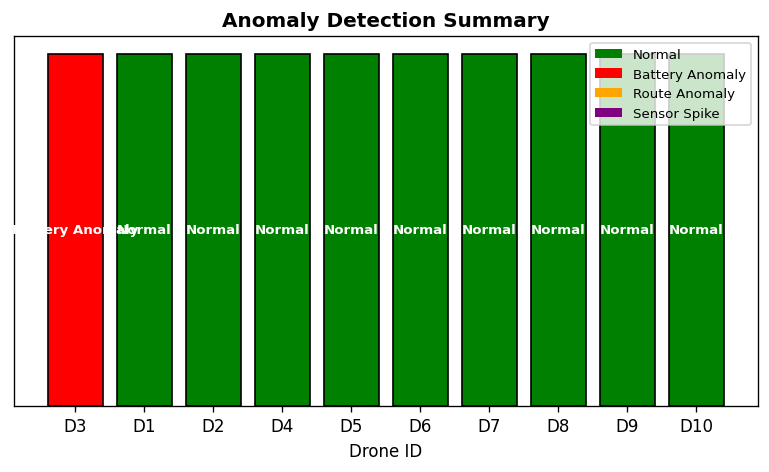


### Simulation Summary


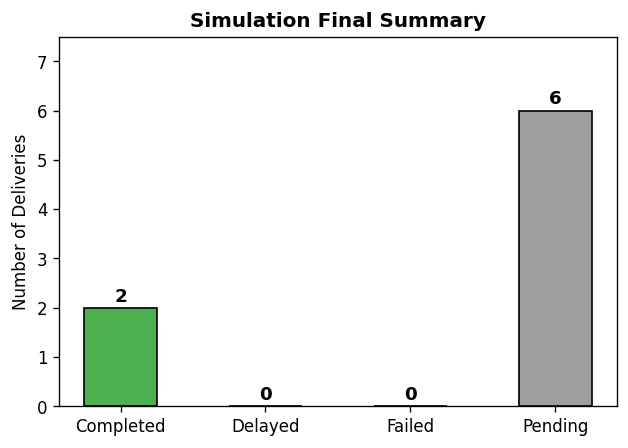

In [66]:
from visualization import generate_all_figures
from IPython.display import Image, display

figure_paths = generate_all_figures(grid, drones, deliveries, summary, anomaly_log)

labels = ["Zone Map", "Route Map", "Demand Heatmap", "Anomaly Summary", "Simulation Summary"]
for label, p in zip(labels, figure_paths):
    print(f"\n### {label}")
    display(Image(p))

---
## Summary of AI Techniques Used

| Step | AI Technique | Key Result |
|------|-------------|------------|
| 1 | Data modelling | 10×10 grid with typed zones, hubs, and flags |
| 2 | CSP validation | R1/R3/R4 pass; R2 flags 7 under-served residential cells |
| 3 | Genetic Algorithm | Optimal fleet selected within budget |
| 4–6 | A* pathfinding | Multi-leg routes computed for all assigned drones |
| 7–14 | Event simulation + rerouting | No-fly disruption handled via live A* re-planning |
| 15–17 | Random Forest Regression | Grid demand updated; high-demand re-dispatch triggered |
| 18 | Random Forest Classification | 4-class anomaly detection at 100% accuracy on synthetic data |
| 19–20 | Post-anomaly response | Critical drone returned, simulation concluded |

---
*AeroNet Lite — Semester 6 AI Project*